<>:130: SyntaxWarning: invalid escape sequence '\D'
<>:133: SyntaxWarning: invalid escape sequence '\D'
<>:133: SyntaxWarning: invalid escape sequence '\l'
<>:130: SyntaxWarning: invalid escape sequence '\D'
<>:133: SyntaxWarning: invalid escape sequence '\D'
<>:133: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1754/2870774259.py:130: SyntaxWarning: invalid escape sequence '\D'
  ax1.set_title(f'High-Resolution Micro-Probing: $\Delta\mu = {DELTA_MU}$ (500 Points)', fontsize=16)
/tmp/ipykernel_1754/2870774259.py:133: SyntaxWarning: invalid escape sequence '\D'
  text_str = f"Probe Window Details:\nWidth ($\Delta\mu$) = {DELTA_MU}\nSteps = $10^7$\nClock = $1/\ln^2(n)$"
/tmp/ipykernel_1754/2870774259.py:133: SyntaxWarning: invalid escape sequence '\l'
  text_str = f"Probe Window Details:\nWidth ($\Delta\mu$) = {DELTA_MU}\nSteps = $10^7$\nClock = $1/\ln^2(n)$"


🚀 启动 500点 极高分辨率扫描 | 游标宽度: Δμ = 0.02
------------------------------------------------------------
[  1/500] 终点 μ_end = 1.3500 | R² = 0.9696 | 误差 = 5.1061
[ 25/500] 终点 μ_end = 1.3644 | R² = 0.9571 | 误差 = 5.2508
[ 50/500] 终点 μ_end = 1.3795 | R² = 0.9689 | 误差 = 8.1905
[ 75/500] 终点 μ_end = 1.3945 | R² = 0.9859 | 误差 = 5.6350
[100/500] 终点 μ_end = 1.4095 | R² = 0.9905 | 误差 = 4.6814
[125/500] 终点 μ_end = 1.4245 | R² = 0.9899 | 误差 = 4.8101
[150/500] 终点 μ_end = 1.4396 | R² = 0.9880 | 误差 = 5.1548
[175/500] 终点 μ_end = 1.4546 | R² = 0.9886 | 误差 = 5.0006
[200/500] 终点 μ_end = 1.4696 | R² = 0.9892 | 误差 = 4.8517
[225/500] 终点 μ_end = 1.4847 | R² = 0.9871 | 误差 = 5.2683
[250/500] 终点 μ_end = 1.4997 | R² = 0.9892 | 误差 = 4.7869
[275/500] 终点 μ_end = 1.5147 | R² = 0.9879 | 误差 = 5.0462
[300/500] 终点 μ_end = 1.5298 | R² = 0.9891 | 误差 = 5.0054
[325/500] 终点 μ_end = 1.5448 | R² = 0.9886 | 误差 = 5.0794
[350/500] 终点 μ_end = 1.5598 | R² = 0.9876 | 误差 = 5.2662
[375/500] 终点 μ_end = 1.5748 | R² = 0.9888 | 误差 = 4.9766
[400/50

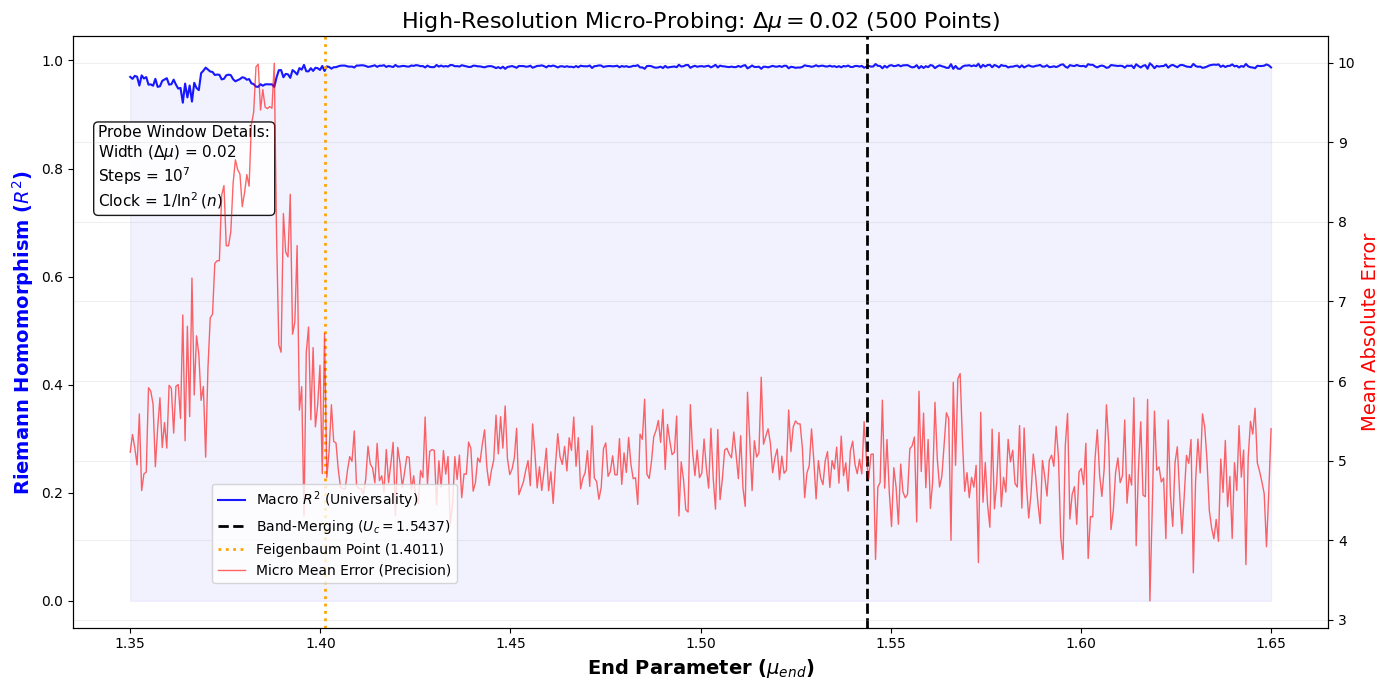

In [1]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import eigs
from scipy.stats import linregress
import mpmath
import matplotlib.pyplot as plt
import time
from numba import njit

# 真实的黎曼零点
mpmath.mp.dps = 15
N_ZEROS = 100
TRUE_ZEROS = np.array([float(mpmath.zetazero(i).imag) for i in range(1, N_ZEROS + 1)])

@njit
def run_micro_universe(steps, n_bins, mu_start, mu_end, c_offset):
    transitions = np.zeros((n_bins, n_bins), dtype=np.uint32)
    x = 0.5
    last_bin = int((x + 1.0) / 2.0 * (n_bins - 1))
    
    # 提取 1/ln^2 时钟的曲率模板
    t_start = 1.0 / (np.log(1.0 + c_offset)**2)
    t_end = 1.0 / (np.log(steps + c_offset)**2)
    
    for i in range(1, steps + 1):
        # 严格遵守 1/ln^2(t) 的非线性时间流逝节奏
        t_curr = 1.0 / (np.log(i + c_offset)**2)
        
        # 将进度映射到 0 ~ 1 之间
        progress = (t_curr - t_start) / (t_end - t_start)
        
        # 精准定位当前的 mu
        mu = mu_start + progress * (mu_end - mu_start)
        
        # 物理保险丝：防止参数溢出炸毁系统
        if mu < 0.1: mu = 0.1
        elif mu > 2.0: mu = 2.0
            
        x = 1.0 - mu * x * x
        if x > 1.0: x = 0.999
        elif x < -1.0: x = -0.999
            
        current_bin = int((x + 1.0) / 2.0 * (n_bins - 1))
        transitions[last_bin, current_bin] += 1
        last_bin = current_bin
        
    return transitions

# ================= 🔬 游标卡尺参数设置区 =================

# 1. 扫描网格（横轴显示结束点）：均匀分布的 500 个点
# 建议范围 1.35 到 1.65，涵盖所有核心相变区
mu_end_points = np.linspace(1.35, 1.65, 500)

# 2. 微扰窗口大小 (游标卡尺的宽度)
# 正数表示从左向右生长 (如 0.02 表示从 mu_end - 0.02 涨到 mu_end)
# 负数表示从右向左退火 (如 -0.02 表示从 mu_end + 0.02 降到 mu_end)
DELTA_MU = 0.02  

# 3. 宇宙演化步长与对数平滑常数
TOTAL_STEPS = 10**7
C_OFFSET = 10**6 

# =======================================================

results_R2 = []
results_mean_err = []

print(f"🚀 启动 500点 极高分辨率扫描 | 游标宽度: Δμ = {DELTA_MU}")
print("-" * 60)
start_total_t = time.time()

for idx, mu_end in enumerate(mu_end_points):
    mu_start = mu_end - DELTA_MU
    
    # 运行微扰演化
    trans = run_micro_universe(TOTAL_STEPS, 5000, mu_start, mu_end, C_OFFSET)
    
    P_sparse = sp.csr_matrix(trans, dtype=np.float64)
    row_sums = np.array(P_sparse.sum(axis=1)).flatten()
    row_sums[row_sums == 0] = 1.0 
    P_sparse.data /= row_sums[P_sparse.indices]
    
    try:
        eigenvalues, _ = eigs(P_sparse, k=N_ZEROS + 20, which='LM', tol=1e-4)
        phases = np.sort(np.angle(eigenvalues[np.abs(eigenvalues.imag) > 1e-4]))
        unwrapped = np.unwrap(phases)
        
        min_len = min(len(unwrapped), N_ZEROS)
        if min_len > 10:
            unwrapped_trunc = unwrapped[:min_len]
            true_zeros_trunc = TRUE_ZEROS[:min_len]
            
            slope, intercept, r_val, _, _ = linregress(unwrapped_trunc, true_zeros_trunc)
            pred = slope * unwrapped_trunc + intercept
            err = np.mean(np.abs(pred - true_zeros_trunc))
            r2 = r_val**2
        else:
            err = 20.0 
            r2 = 0.0
    except Exception:
        err = 20.0
        r2 = 0.0
        
    results_R2.append(r2)
    results_mean_err.append(err)
    
    # 打印进度条：每 25 个点汇报一次，避免刷屏
    if (idx + 1) % 25 == 0 or idx == 0:
        print(f"[{idx+1:3d}/500] 终点 μ_end = {mu_end:.4f} | R² = {r2:.4f} | 误差 = {err:.4f}")

print("-" * 60)
print(f"✅ 超清扫描完成！总耗时: {(time.time()-start_total_t)/60:.2f} 分钟")

# ================= 绘图环节 =================
fig, ax1 = plt.subplots(figsize=(14, 7))

ax1_twin = ax1.twinx()
ax1.plot(mu_end_points, results_R2, 'b-', lw=1.5, alpha=0.9, label='Macro $R^2$ (Universality)')
ax1.fill_between(mu_end_points, results_R2, color='blue', alpha=0.05)

ax1_twin.plot(mu_end_points, results_mean_err, 'r-', lw=1.0, alpha=0.6, label='Micro Mean Error (Precision)')

ax1.axvline(1.543689, color='k', linestyle='--', lw=2, label='Band-Merging ($U_c=1.5437$)')
ax1.axvline(1.401155, color='orange', linestyle=':', lw=2, label='Feigenbaum Point (1.4011)')

ax1.set_xlabel(r'End Parameter ($\mu_{end}$)', fontsize=14, fontweight='bold')
ax1.set_ylabel(r'Riemann Homomorphism ($R^2$)', color='b', fontsize=14, fontweight='bold')
ax1_twin.set_ylabel('Mean Absolute Error', color='r', fontsize=14)
ax1.set_title(f'High-Resolution Micro-Probing: $\Delta\mu = {DELTA_MU}$ (500 Points)', fontsize=16)

# 添加悬浮窗说明
text_str = f"Probe Window Details:\nWidth ($\Delta\mu$) = {DELTA_MU}\nSteps = $10^7$\nClock = $1/\ln^2(n)$"
ax1.text(0.02, 0.85, text_str, transform=ax1.transAxes, fontsize=11,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

fig.legend(loc='lower left', bbox_to_anchor=(0.15, 0.15), ncol=1)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()